# Reconstructing the past: estimating solar radio flux F10.7 from sunspot records
# Ilya Niafiodau, Vlad Zagorodnyuk, Zhanar Sirgebayeva, Skoltech, 2026

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# read data from the .txt files
flux_year, flux_month, flux = np.loadtxt("Radio_flux_monthly_mean.txt", unpack=True)
sunspot_year, sunspot_month, sunspot = np.loadtxt("Sunspot_number_monthly_mean.txt", unpack=True)

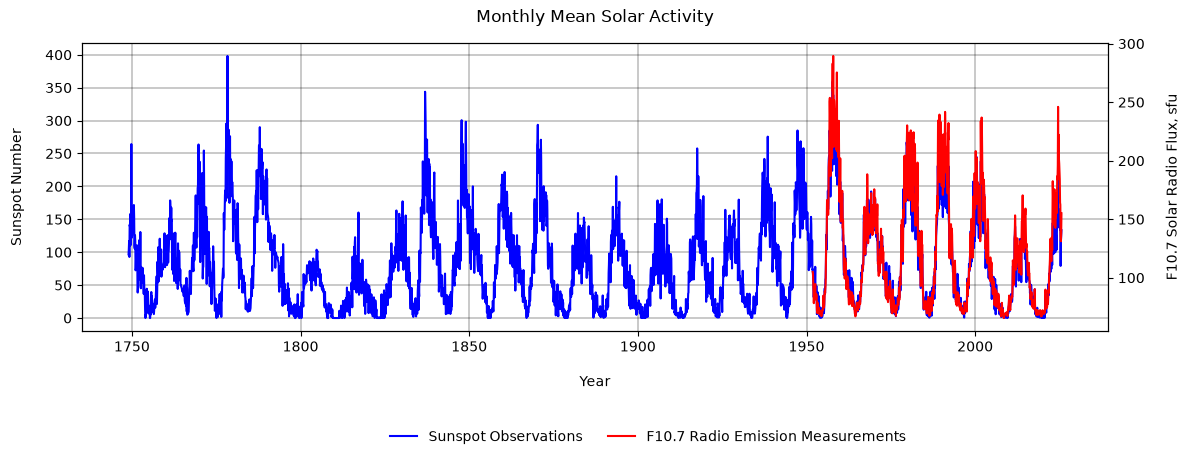

In [24]:
# establish a decimal year time axis
flux_time    = flux_year    + (flux_month    - 1) / 12
sunspot_time = sunspot_year + (sunspot_month - 1) / 12

# plot the monthly mean sunspot number 
# and solar radio flux at 10.7 cm in one chart
def plot_solar_activity_over_time(
    title, x1_data, y1_data, y1_ax_name, x2_data, y2_data, y2_ax_name, is_scatter_plot
):
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # left y-axis: sunspot number
    if is_scatter_plot:
        ax1.scatter(
            x1_data, 
            y1_data, 
            s=2,
            color="blue", 
            label="Sunspot Observations"
        )
    else:
        ax1.plot(
            x1_data, 
            y1_data, 
            color="blue", 
            label="Sunspot Observations"
        )
    ax1.set_title(title, pad=15) 
    ax1.set_xlabel("Year", labelpad=15)
    ax1.set_ylabel(y1_ax_name, labelpad=15) 
    ax1.grid(True, color="black", linewidth=0.3)
    ax1.tick_params(axis="y")
    ax1.legend(
        frameon=False, 
        markerscale=4, 
        ncol=2, 
        loc="upper right", 
        bbox_to_anchor=(0.5, -0.3)
    )

    # right y-axis: F10.7 solar radio flux
    ax2 = ax1.twinx()
    if is_scatter_plot:
        ax2.scatter(
            x2_data, 
            y2_data, 
            s=2,
            color="red", 
            label="F10.7 Radio Emission Measurements"
        )
    else:
        ax2.plot(
            x2_data, 
            y2_data, 
            color="red", 
            label="F10.7 Radio Emission Measurements"
        )
    ax2.set_ylabel(y2_ax_name, labelpad=15) 
    ax2.legend(
        frameon=False, 
        markerscale=4, 
        ncol=2, 
        loc="upper left", 
        bbox_to_anchor=(0.5, -0.3)
    )

    fig.tight_layout()
    plt.show()

# call the self-written function above to plot the datasets from the files
plot_solar_activity_over_time(
    title="Monthly Mean Solar Activity",
    x1_data=sunspot_time,
    y1_data=sunspot,
    y1_ax_name="Sunspot Number",
    x2_data=flux_time,
    y2_data=flux,
    y2_ax_name="F10.7 Solar Radio Flux, sfu",
    is_scatter_plot=False
)

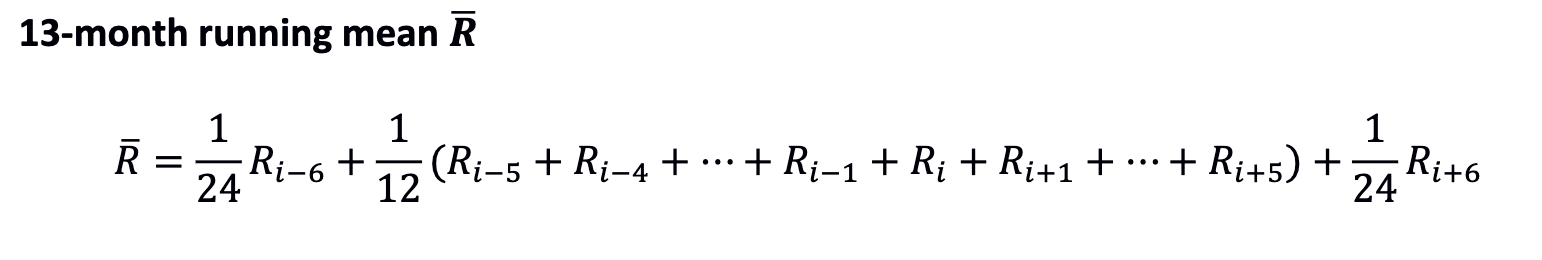

In [7]:
# apply a 13-month running mean 

def smooth(data, time):
    n = len(time)
    running_mean_13 = data.copy()

    for i in range(6, n - 6):
        mean = (data[i-6] + data[i+6]) / 24

        for j in range(i-5, i+6):
            mean += data[j] / 12

        running_mean_13[i] = mean

    return running_mean_13

sunspot_smoothed = smooth(sunspot, sunspot_time)
flux_smoothed = smooth(flux, flux_time)
   

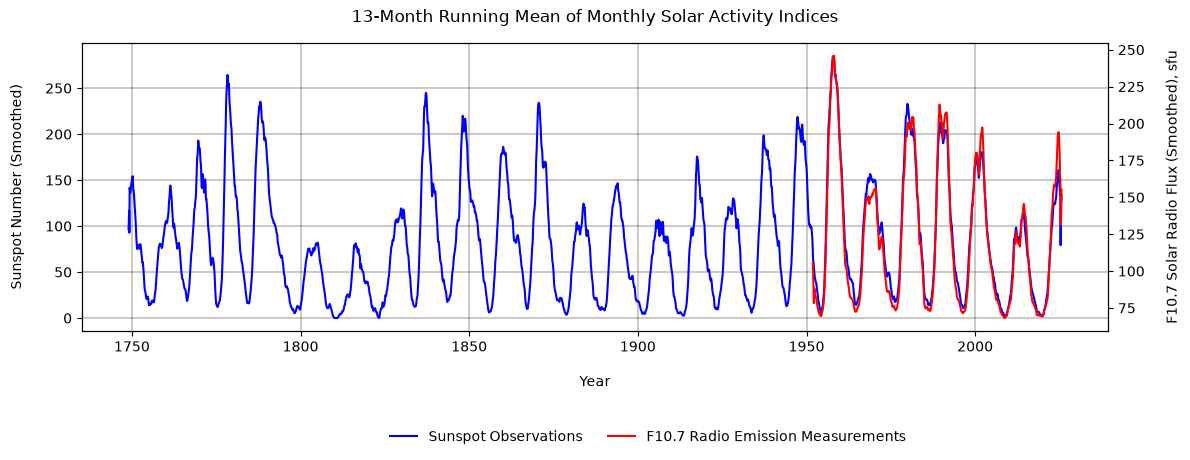

In [26]:
# call the self-written function above to plot the smoothed datasets
plot_solar_activity_over_time(
    title="13-Month Running Mean of Monthly Solar Activity Indices",
    x1_data=sunspot_time,
    y1_data=sunspot_smoothed,
    y1_ax_name="Sunspot Number (Smoothed)",
    x2_data=flux_time,
    y2_data=flux_smoothed,
    y2_ax_name="F10.7 Solar Radio Flux (Smoothed), sfu",
    is_scatter_plot=False
)

Start of the overlap is 1951.833.
End of the overlap is 2025.583.


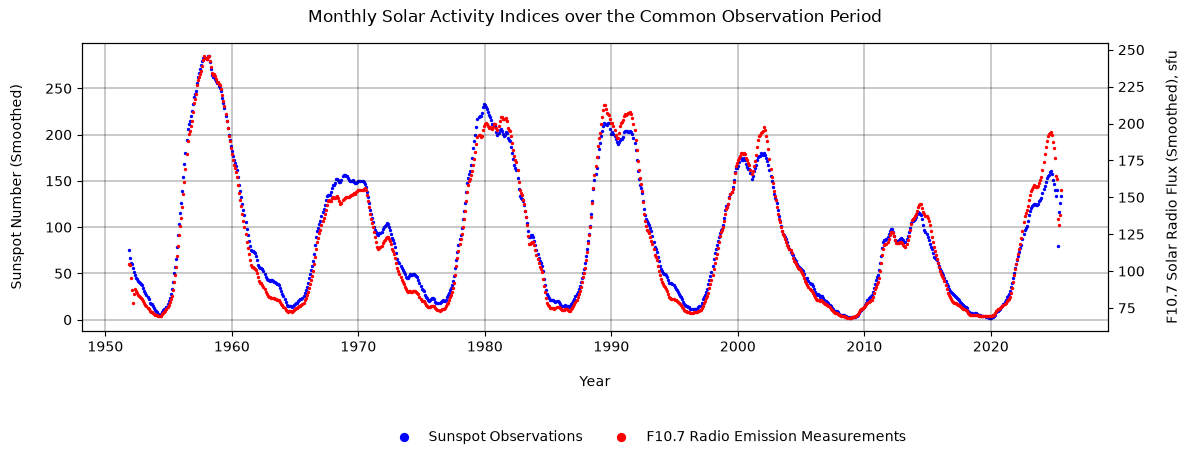

In [ ]:
# find an overlapping time frame
common_start = max(sunspot_time[0], flux_time[0])
common_end = min(sunspot_time[-1], flux_time[-1])
print("Start of the overlap is %.3f.\nEnd of the overlap is %.3f." % (common_start, common_end))
sunspot_mask = (sunspot_time >= common_start) & (sunspot_time <= common_end)
flux_mask = (flux_time >= common_start) & (flux_time <= common_end)

# extract data from the common timeline
common_time = sunspot_time[sunspot_mask]
sunspot_smoothed_common = sunspot_smoothed[sunspot_mask]
flux_smoothed_common = flux_smoothed[flux_mask]

# call the self-written function above to make a scatter plot over the found overlapping period
plot_solar_activity_over_time(
    title="Monthly Solar Activity Indices over the Common Observation Period",
    x1_data=common_time,
    y1_data=sunspot_smoothed_common,
    y1_ax_name="Sunspot Number (Smoothed)",
    x2_data=common_time,
    y2_data=flux_smoothed_common,
    y2_ax_name="F10.7 Solar Radio Flux (Smoothed), sfu",
    is_scatter_plot=True
)

# Conclusions:
both dependencies have:
- same periods
- same max and mins points (extremums)

looks like they have a linear dependency

# Multi-dimensional linear regression model:
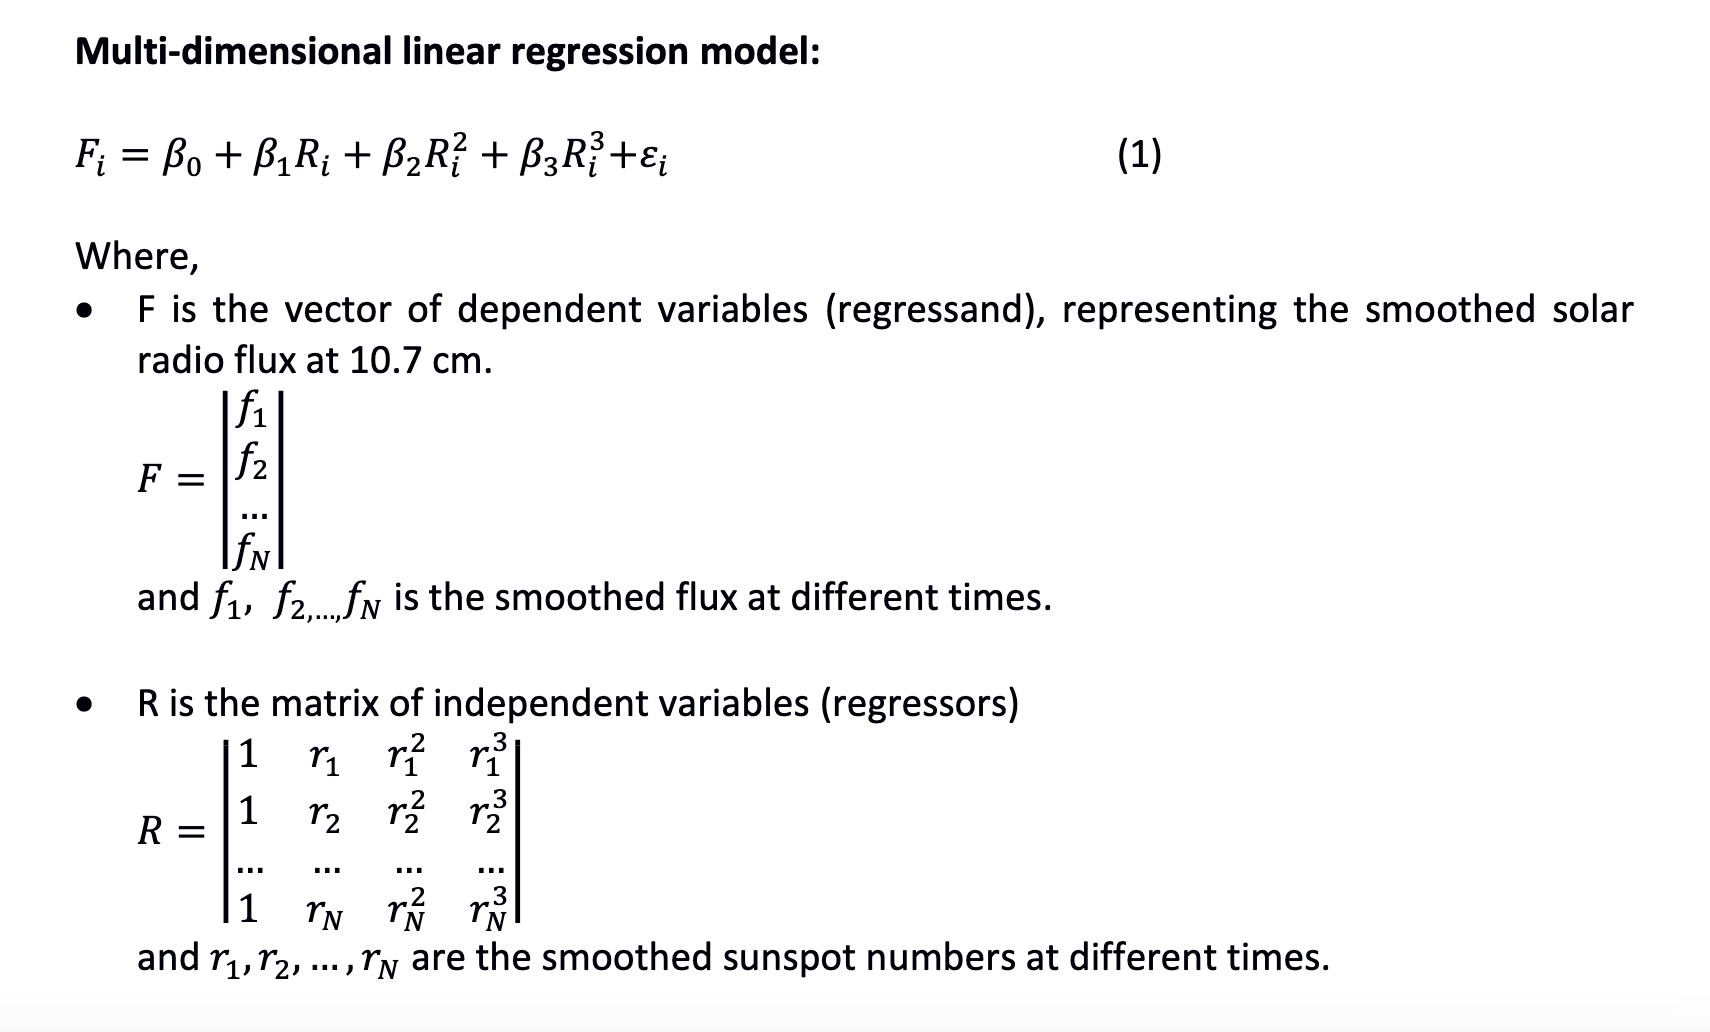
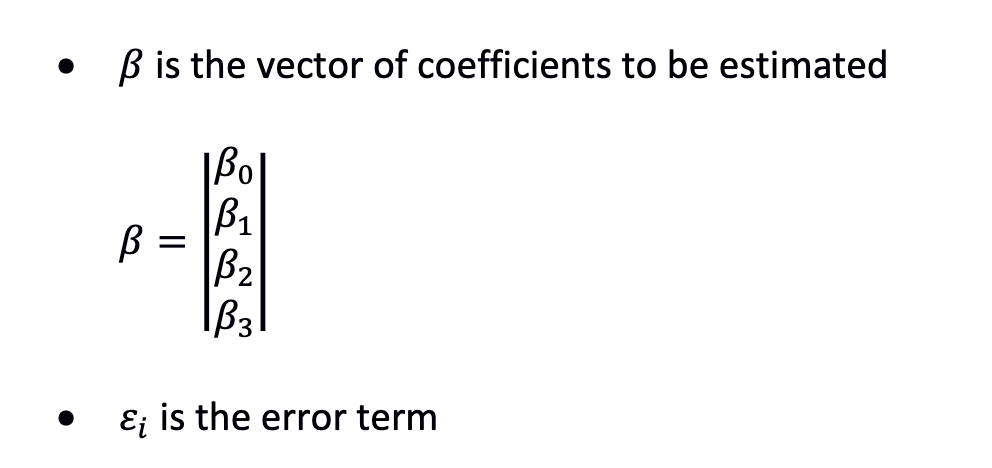

In [41]:
r = sunspot_smoothed_common
f = flux_smoothed_common

# create a matrix of regressors with rows following the pattern: 1, r_i, r_i^2, r_i^3
R = np.column_stack((np.ones(r.size), r, r**2, r**3))

# create a vector of regressands by reshaping the array f
F = f.reshape(-1, 1)

# define a vector of regression coefficients using the LSM
beta = np.linalg.inv(R.T @ R) @ R.T @ F

print("R:", R.shape, " F:", F.shape, " beta:", beta.shape, "\n")
print("beta = %s" % beta)

R: (886, 4)  F: (886, 1)  beta: (4, 1) 

beta = [[ 6.57530080e+01]
 [ 4.70189358e-01]
 [ 1.92170969e-03]
 [-5.07032158e-06]]


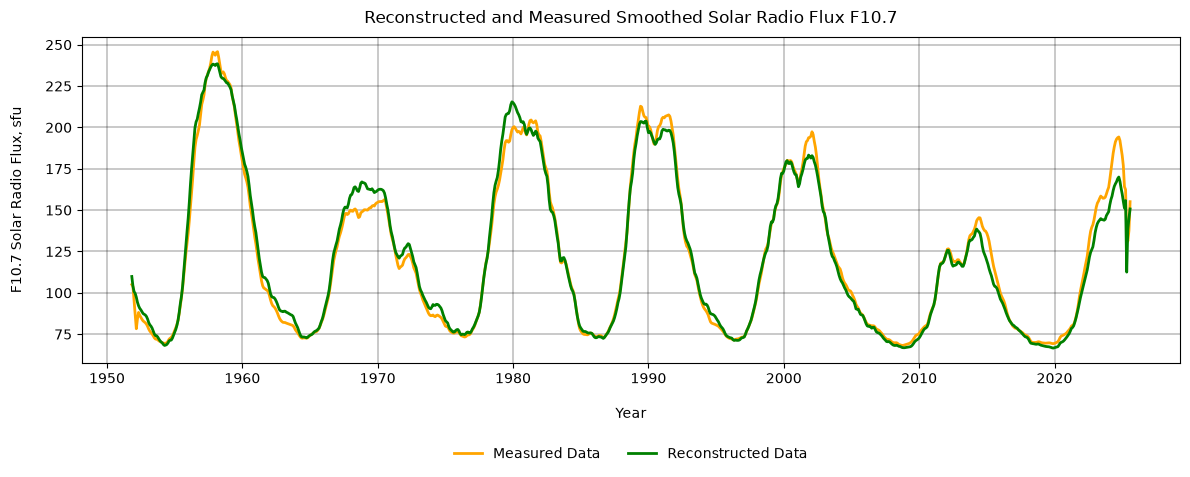

In [48]:
# reconstruct the smoothed F10.7 flux:
# F = beta0 + beta1*r + beta2*r^2 + beta3*r^3
F_reconstructed = R @ beta
flux_array_reconstructed = F_reconstructed.ravel()

# plot the reconstructed F10.7 flux and the initial smoothed F10.7 flux in a single chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(common_time, flux_smoothed_common, linewidth=2, color="orange", label="Measured Data")
ax.plot(common_time, flux_array_reconstructed, linewidth=2, color="green", label="Reconstructed Data")
ax.set_title("Reconstructed and Measured Smoothed Solar Radio Flux F10.7", pad=10)
ax.set_xlabel("Year", labelpad=15)
ax.set_ylabel("F10.7 Solar Radio Flux, sfu", labelpad=15)
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22))
fig.tight_layout()
plt.show()

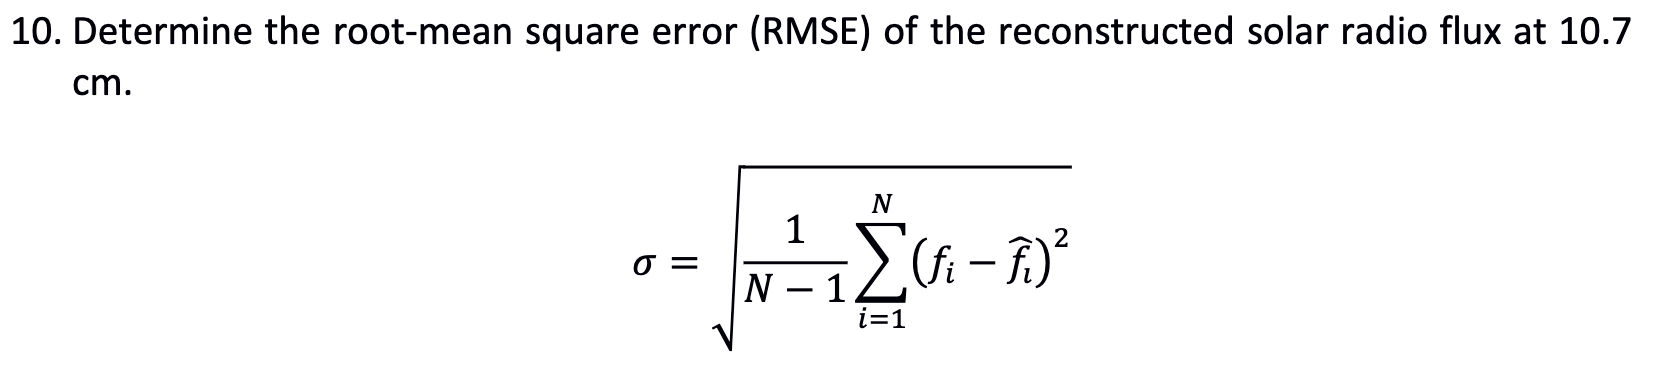

In [50]:
N = flux_array_reconstructed.size
squared_error = 0

for i in range(N):
    error = flux_array_reconstructed[i] - flux_smoothed_common[i]
    squared_error += error**2

rmse = (squared_error / (N - 1))**0.5

print("RMSE: ", rmse)

RMSE:  6.2253299836630545


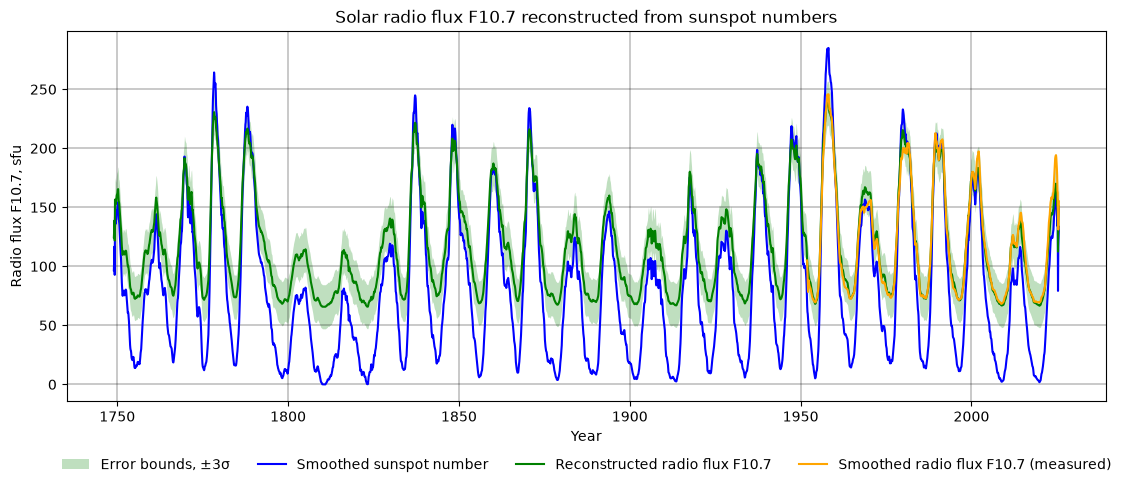

In [51]:
# apply the model to the whole period where sunspot numbers are available
r_full = sunspot_smoothed
R_full = np.column_stack((np.ones(r_full.size), r_full, r_full**2, r_full**3))
flux_array_reconstructed_full = (R_full @ beta).ravel()

# error bounds: +-3 sigma
flux_full_lower = flux_array_reconstructed_full - 3 * rmse
flux_full_upper = flux_array_reconstructed_full + 3 * rmse

# plotting
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(sunspot_time, flux_full_lower, flux_full_upper, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.plot(sunspot_time, sunspot_smoothed, linewidth=1.5, color="blue", label="Smoothed sunspot number")
ax.plot(sunspot_time, flux_array_reconstructed_full, linewidth=1.5, color="green", label="Reconstructed radio flux F10.7")
ax.plot(common_time, flux_smoothed_common, linewidth=1.5, color="orange", label="Smoothed radio flux F10.7 (measured)")
ax.set_title("Solar radio flux F10.7 reconstructed from sunspot numbers")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

measured points inside ±3σ: 873 of 886 (98.5%)


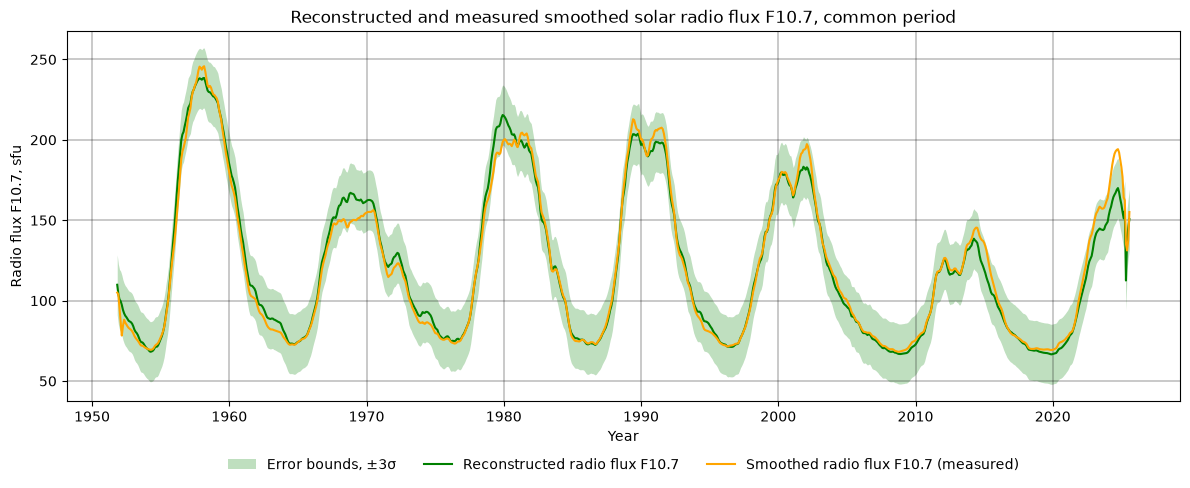

In [52]:
# reconstructed model with +-3 sigma band and measured points on the common period
flux_common_lower = flux_array_reconstructed - 3 * rmse
flux_common_upper = flux_array_reconstructed + 3 * rmse

inside = (flux_smoothed_common >= flux_common_lower) & (flux_smoothed_common <= flux_common_upper)
print(f"measured points inside ±3σ: {inside.sum()} of {inside.size} ({100 * inside.mean():.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(common_time, flux_common_lower, flux_common_upper, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.plot(common_time, flux_array_reconstructed, linewidth=1.5, color="green", label="Reconstructed radio flux F10.7")
ax.plot(common_time, flux_smoothed_common, linewidth=1.5, color="orange", label="Smoothed radio flux F10.7 (measured)")
ax.set_title("Reconstructed and measured smoothed solar radio flux F10.7, common period")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

# Same model without smoothing
Repeat all steps on raw monthly mean data and compare RMSE with the smoothed case.

In [ ]:
# re-read raw data: smooth() above overwrites the flux and sunspot arrays
flux_raw = np.loadtxt("Radio_flux_monthly_mean.txt", unpack=True)[2]
sunspot_raw = np.loadtxt("Sunspot_number_monthly_mean.txt", unpack=True)[2]

r_raw = sunspot_raw[sunspot_mask]
f_raw = flux_raw[flux_mask]

# R: (1, r_i, r_i^2, r_i^3) - one row per month
# F: column of f_i
R_raw = np.column_stack((np.ones(r_raw.size), r_raw, r_raw**2, r_raw**3))
F_raw = f_raw.reshape(-1, 1)

# Least squares estimate: beta = (R^T R)^-1 R^T F
beta_raw = np.linalg.inv(R_raw.T @ R_raw) @ R_raw.T @ F_raw
flux_array_reconstructed_raw = (R_raw @ beta_raw).ravel()

rmse_raw = sqrt(((flux_array_reconstructed_raw - f_raw) ** 2).sum() / (len(f_raw) - 1))

print("R:", R_raw.shape, " F:", F_raw.shape, " beta:", beta_raw.shape)
print(beta_raw)
print(rmse_raw, 3 * rmse_raw)

R: (886, 4)  F: (886, 1)  beta: (4, 1)
[[ 6.53916635e+01]
 [ 5.27898562e-01]
 [ 1.16570840e-03]
 [-2.84574209e-06]]
10.472863444393711 31.418590333181136


measured points inside ±3σ: 868 of 886 (98.0%)


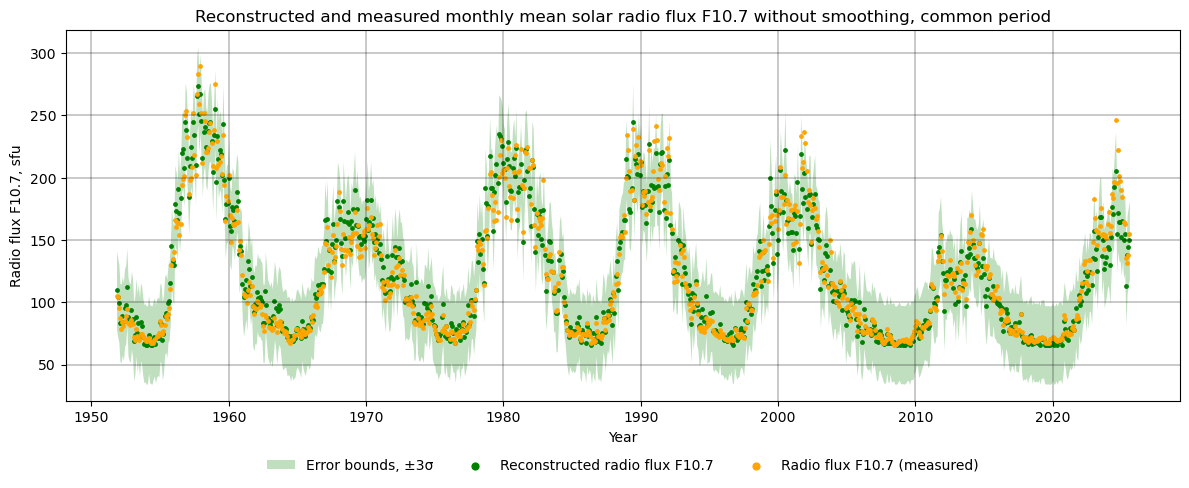

In [ ]:
# raw model with +-3 sigma band and measured points on the common period
flux_common_lower_raw = flux_array_reconstructed_raw - 3 * rmse_raw
flux_common_upper_raw = flux_array_reconstructed_raw + 3 * rmse_raw

inside_raw = (f_raw >= flux_common_lower_raw) & (f_raw <= flux_common_upper_raw)
print(f"measured points inside ±3σ: {inside_raw.sum()} of {inside_raw.size} ({100 * inside_raw.mean():.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(common_time, flux_common_lower_raw, flux_common_upper_raw, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.scatter(common_time, flux_array_reconstructed_raw, s=6, color="green", label="Reconstructed radio flux F10.7")
ax.scatter(common_time, f_raw, s=6, color="orange", label="Radio flux F10.7 (measured)")
ax.set_title("Reconstructed and measured monthly mean solar radio flux F10.7 without smoothing, common period")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, markerscale=2, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

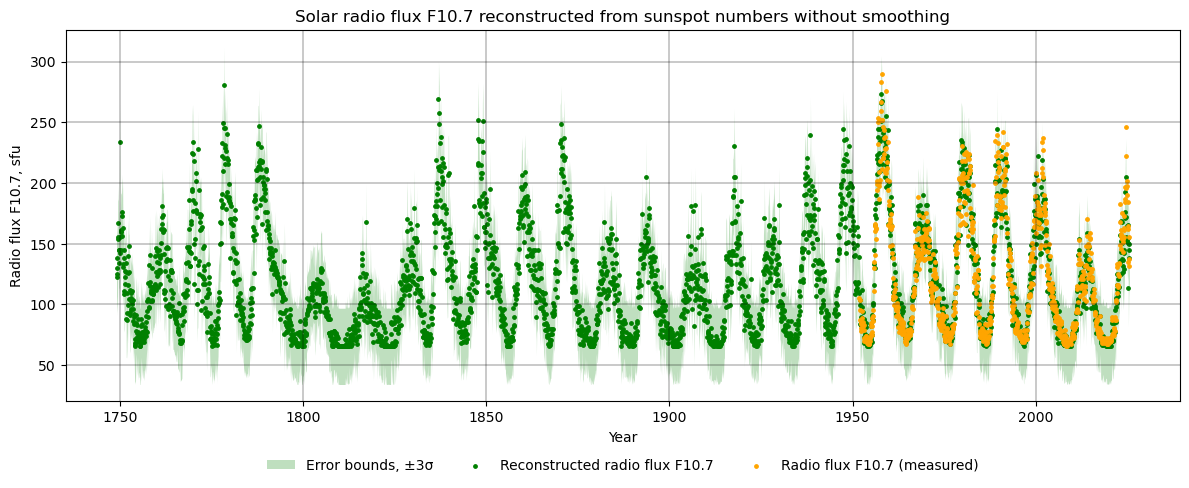

In [ ]:
# apply the raw model to the whole period where sunspot numbers are available
R_full_raw = np.column_stack((np.ones(sunspot_raw.size), sunspot_raw, sunspot_raw**2, sunspot_raw**3))
flux_array_reconstructed_full_raw = (R_full_raw @ beta_raw).ravel()

# error bounds: +-3 sigma
flux_full_lower_raw = flux_array_reconstructed_full_raw - 3 * rmse_raw
flux_full_upper_raw = flux_array_reconstructed_full_raw + 3 * rmse_raw

# plotting
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(sunspot_time, flux_full_lower_raw, flux_full_upper_raw, color="green", alpha=0.25, linewidth=0, label="Error bounds, ±3σ")
ax.scatter(sunspot_time, flux_array_reconstructed_full_raw, s=6, color="green", label="Reconstructed radio flux F10.7")
ax.scatter(common_time, f_raw, s=6, color="orange", label="Radio flux F10.7 (measured)")
ax.set_title("Solar radio flux F10.7 reconstructed from sunspot numbers without smoothing")
ax.set_xlabel("Year")
ax.set_ylabel("Radio flux F10.7, sfu")
ax.grid(True, color="black", linewidth=0.3)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
plt.show()

In [22]:
# compare RMSE with and without smoothing
print(f"{'':42s}{'sigma, sfu':>12s}{'3 sigma, sfu':>14s}")
print(f"{'with smoothing (vs smoothed flux)':42s}{rmse:12.2f}{3 * rmse:14.2f}")
print(f"{'without smoothing (vs raw flux)':42s}{rmse_raw:12.2f}{3 * rmse_raw:14.2f}")

                                            sigma, sfu  3 sigma, sfu
with smoothing (vs smoothed flux)                 9.39         28.18
without smoothing (vs raw flux)                  10.47         31.42
